In [72]:
import sys
print(sys.executable)

/bin/python


In [73]:
# Import the libraries
import pandas as pd
import numpy as np
print(pd.__version__)

2.3.3


In [74]:
# Load the Files
file_path = "../data/raw/credit_risk_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [75]:
# Basic Information about the dataset
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [76]:
#Checking the Missing Values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [77]:
# Data imbalance inquiry
df.head()
df['loan_status'].unique()
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

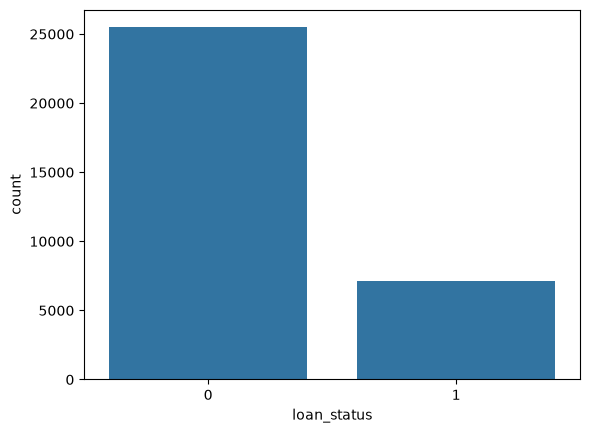

In [78]:
import seaborn as sns
sns.countplot(x='loan_status', data=df)

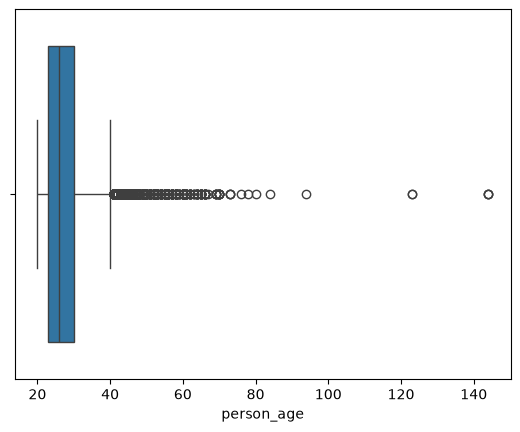

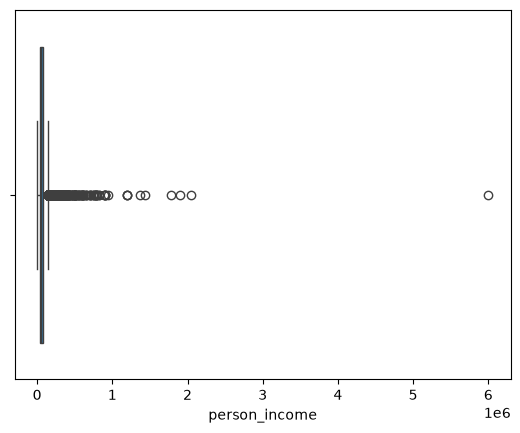

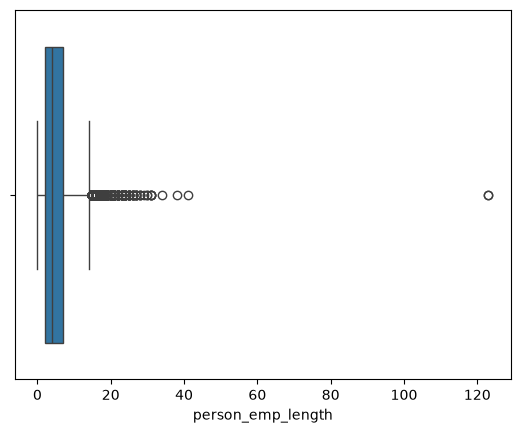

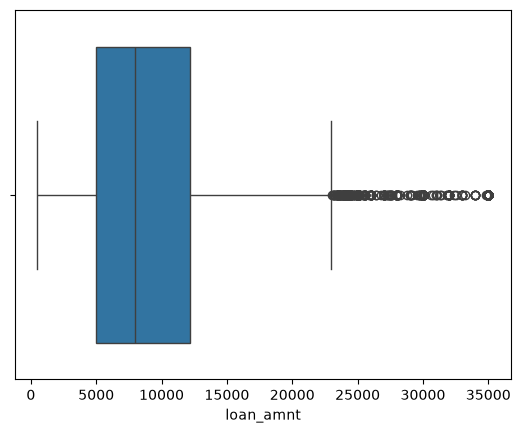

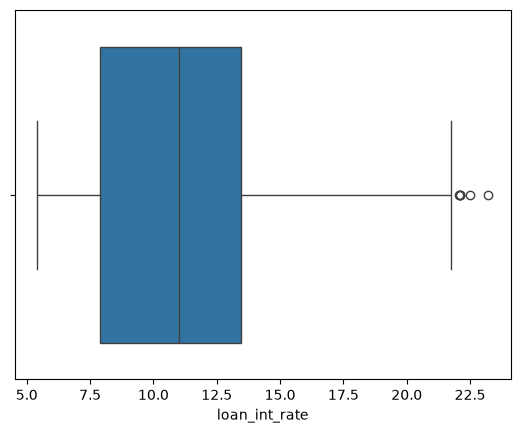

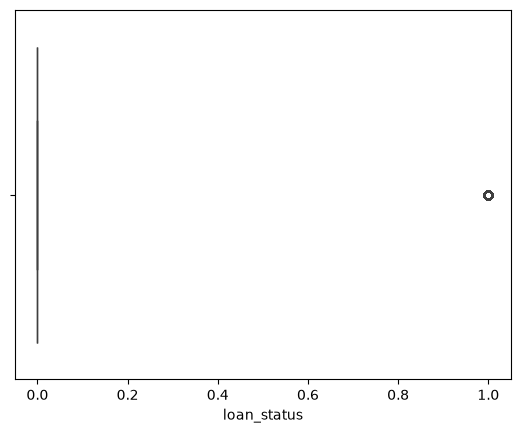

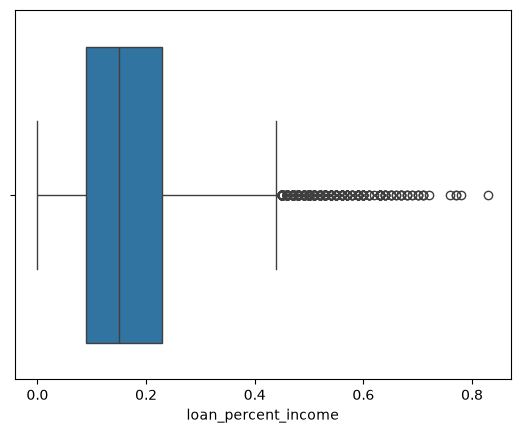

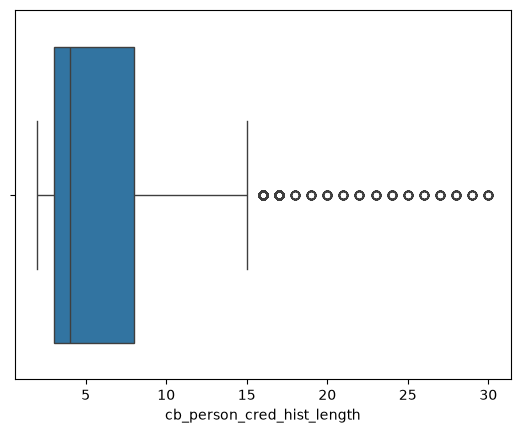

In [79]:
import matplotlib.pyplot as plt
# Checking for outliers
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [80]:
# checking for outliers in person_age column
(df['person_age'] > 100).sum()

np.int64(5)

In [81]:
# checkinf the outliers in person_emp_length column
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [82]:
# Describing the dataset
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

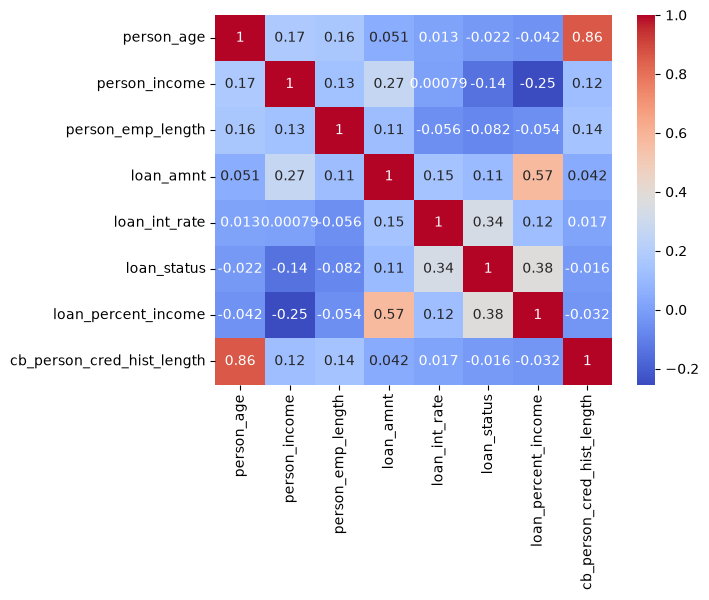

In [83]:
# Correlation between the numerical columns
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')


In [84]:
# Copy of the df
df_copy = df.copy()

# Print the rows before removing duplicates
print(f"Rows before removing duplicates: {df_copy.shape[0]}")

# Remove the duplicate rows
df_copy.drop_duplicates(inplace=True)

# Print the rows after removing the duplicates
print(f"Rows after removing duplicates: {df_copy.shape[0]}")

# Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

# Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

# Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

# check if the interest rate looks realistic.
print("Loan interest rate range from (min: 5.42 and max: 23.22)")


Rows before removing duplicates: 32581
Rows after removing duplicates: 32416
Loan interest rate range from (min: 5.42 and max: 23.22)


### Creating Feature and Target Variable

In [85]:
# Creating X wiith only feature removing target variable i.e., loan_status
X = df_copy.drop('loan_status', axis=1)

# Creating Y with only target variable i.e., loan_status
Y = df_copy['loan_status']

In [86]:
# Importing train_test_split from sklearn
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [87]:
# Seperating numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns   

# Seperating categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

### Handling Class Imbalance
* Very few people actually default in this data.
* If we ignore this, the model may just favor the majority class.
* We give more importance to the minority class during training.
* This helps the model actually learn to spot defaulters


In [88]:
# Handling class imbalance
neg, pos = np.bincount(Y_train)
scale_weigths = neg/pos

print(f"Scale weights: {scale_weigths}")

Scale weights: 3.6312213039485766


### Preprocessing for the Logistic Regression
* Fill missing numeric values.
* Scale numeric values, since this model is sensitive to scale.
* Convert category columns into numbers using one-hot encoding.

In [89]:
# Importing pipeline, column transformer, simple imputer, one hot encoder, standard scaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Comumn transformer for numerical and categorical columns
preprocessor_lr = ColumnTransformer(
    transformers = [
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)  
        ])               

### Preprocessing for XGBoost
* Fill missing numeric values.
* No scaling needed here, since tree models don't need it.
* Convert category columns into numbers using one-hot encoding.


In [90]:
# No Scaling just imputing anf one hot encoding for categorical columns

preprocessor_xg = ColumnTransformer(
    transformers = [
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])         

### Helper Function for Evaluation of Models
* Goal: Build a common function to check any model performance
* It will show accuracy, recall, precision, F1-score, and more.
* It will also show a confusion metrix and precision-recall curve


In [ ]:
# Importing all the libraries for the models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc

def evaluate_model(model_name, model, X_test, Y_test, threshold = None):
    """
    Evaluate the model performance on the test set and print the metrics.
    
    Parameters:
    model_name (str): Name of the model.
    model: Trained model object.
    X_test: Test features.
    Y_test: True labels for the test set.
    threshold (float, optional): Threshold for binary classification. If None, default threshold of 0.5 is used.
    
    Returns:
    None
    """
    
    # Predict probabilities
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Apply threshold if provided
    if threshold is not None:
        y_pred = (y_probs >= threshold).astype(int)
    else:
        y_pred = (y_probs >= 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)

    confusion = confusion_matrix(Y_test, y_pred)
    classification_rep = classification_report(Y_test, y_pred)
    
    # Print metrics
    print(f"Model: {model_name}")
    if threshold is not None:
        print(f"Threshold: {threshold}")    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print ("Classification Report:\n", classification_rep)

    # Plotting confusion matrix
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()  

    # Plotting ROC Curve
    precision, recalls, thresholds = precision_recall_curve(Y_test, y_probs)
    plt.plot(recalls, precision, marker='.')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()